# Post-processing of the Delphes v2 files: variables requested by the referee

- Major 2 (TDA redundancy): scalar energy sum ΣE, EFlow multiplicity, transverse sphericity, transverse thrust, N-subjettiness ratios
- Major 3 (boosted substructure): soft-drop mass, τ21, D2, N2

**References**
- Energy correlation functions: arXiv:1305.0007, eqs. (2.2), (2.4)–(2.6)
- $D_2 = e_3/e_2^3$: arXiv:1409.6298, eqs. (2.1), (2.2), (3.9)
- $N_2 = {}_2e_3/({}_1e_2)^2$: arXiv:1609.07483, eqs. (3.3), (3.12)
- N-subjettiness $\tau_N$: arXiv:1011.2268, eq. (2.1)
- Soft drop: arXiv:1402.2657, eq. (1.1)
- Transverse thrust: arXiv:hep-ph/0407287, eq. (3.1); ATLAS, arXiv:1207.6915, eq. (1)
- Transverse sphericity (linearised, collinear safe): ALICE, EPJC 72 (2012) 2124, arXiv:1205.3963, eq. (1) and the linearised matrix $S^{xy}_L$ above it
- Jet reconstruction efficiency and the 10° nozzle dead zone: EPJC 86 (2026) 554 (arXiv:2511.23273), Fig. 24

### Input file and branches
`entry_stop=2000` reads only the first 2000 events. `J0` is the default branch of `J`, used for the MUSIC mass scaling and the efficiency below. `pt_min` is applied to both fat jets.

In [1]:
import time
t1 = time.time()

import uproot
import numpy as np
import matplotlib.pyplot as plt

fname = '/data/mucollider/two_boosted/3TeV/hhvv_500K/delphes_output_v2.root'
J = 'VLCjetR10N2'    # fat jets; or 'VLCjetR10N2_MUSIC'
# J = 'VLCjetR10N2_MUSIC'    # fat jets; or 'VLCjetR10N2_MUSIC'
J0 = J.replace('_MUSIC', '')

branches = [f'{J}.PT', f'{J}.Eta', f'{J}.Phi', f'{J}.Mass', f'{J}.BTag', f'{J}.Tau[5]', f'{J}.SoftDroppedP4[5]',
            f'{J}.NSubJetsSoftDropped', f'{J}.Constituents', f'{J0}.PT', f'{J0}.Eta', f'{J0}.Phi', 'MissingET.MET', 'ScalarHT.HT',
            'EFlowTrack.fUniqueID', 'EFlowTrack.PT', 'EFlowTrack.Eta', 'EFlowTrack.Phi',
            'EFlowPhoton.fUniqueID', 'EFlowPhoton.ET', 'EFlowPhoton.Eta', 'EFlowPhoton.Phi',
            'EFlowNeutralHadron.fUniqueID', 'EFlowNeutralHadron.ET', 'EFlowNeutralHadron.Eta', 'EFlowNeutralHadron.Phi']
events = uproot.open(fname)['Delphes'].arrays(branches, entrystop=500000)

# 1. 取得所有 branch 的名稱（若為 Uproot 3，key 可能是 bytes，可順便 decode 成 str）
keys = [k.decode('utf-8') if isinstance(k, bytes) else k for k in events.keys()]

# 2. 一行轉置成 2000 個 event 的 list
events = [dict(zip(keys, row)) for row in zip(*events.values())]

# 檢查結果
print(len(events))  # 輸出: 2000
print(len(events[0]))  # 輸出: 26 (第 0 個 event 裡有 26 個 branch)

# 取用方式：第 0 個 event 的 VLCjetR10N2.PT
print(events[0]['VLCjetR10N2.PT'])

/usr/local/lib/python3.8/dist-packages/awkward/array/base.py:394: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return cls.numpy.array(value, copy=False)


500000
23
[176.51427 145.68332]


## Variables stored by Delphes

### b-tag bits
bit 0: WP50, bit 1: WP70, bit 2: MUSIC tag

In [2]:
def btag(ev, j, bit):
    return (ev[f'{J}.BTag'][j] >> bit) & 1

### N-subjettiness ratios τ21, τ32
`Tau[0]` … `Tau[4]` = τ1 … τ5 (arXiv:1011.2268, eq. (2.1)) NaN when the denominator is 0 (jets with one or two constituents).

In [3]:
def tau_ratios(ev, j):
    tau = ev[f'{J}.Tau[5]'][j]
    return tau[1] / tau[0], tau[2] / tau[1]

### Soft-drop mass and number of SoftDrop subjets
`SoftDroppedP4[0]` = groomed jet, `[1]`, `[2]` = the two subjets (TLorentzVector: `fP` = (x, y, z), `fE`)

In a `_MUSIC` branch Delphes smears only the jet pT; the jet mass and the SoftDrop 4-vectors are copied from the unsmeared jet. `music_scale` returns pT(`_MUSIC`)/pT(default) of the same jet (matched in η, φ); the loop below multiplies both m_SD and the jet mass M(J) by it. It is 1 for a default branch.

In [4]:
# def mass(p4):
#     return np.sqrt(max(p4['fE']**2 - p4['fP']['fX']**2 - p4['fP']['fY']**2 - p4['fP']['fZ']**2, 0))

def mass(p4):
    return np.sqrt(max(p4.t**2 - p4.x**2 - p4.y**2 - p4.z**2, 0))

def softdrop(ev, j):
    return mass(ev[f'{J}.SoftDroppedP4[5]'][j*5]), ev[f'{J}.NSubJetsSoftDropped'][j]

def music_scale(ev, j):
    if J == J0:
        return 1.0
    k = np.argmin((ev[f'{J0}.Eta'] - ev[f'{J}.Eta'][j])**2 + (ev[f'{J0}.Phi'] - ev[f'{J}.Phi'][j])**2)
    return ev[f'{J}.PT'][j] / ev[f'{J0}.PT'][k]

### Event level: MET, HT

In [5]:
def event_level(ev):
    return ev['MissingET.MET'][0], ev['ScalarHT.HT'][0]

## Variables computed here

### Jet reconstruction efficiency and angular acceptance
`eff_edges`, `eff_val`: b-jet reconstruction efficiency vs Monte Carlo jet $p_T$, EPJC 86 (2026) 554, Fig. 24: the published value of each of the 10 bins (18 GeV wide, 20–200 GeV), used flat within the bin (no interpolation); $p_T$ ≥ 200 GeV takes the 182–200 GeV value. `eta_max`: θ > 10° (nozzle dead zone), i.e. |η| < 2.436, applied to the fat-jet axis. The efficiency is evaluated at the default-branch pT (closest to the true jet pT). The curve is measured for R = 0.5 jets and is almost flat (≈ 0.98) above 100 GeV, so for boosted fat jets it acts mainly as a normalisation.

In [6]:
eff_edges = np.array([20, 38, 56, 74, 92, 110, 128, 146, 164, 182, 200])
eff_val   = np.array([81.8, 93.9, 95.6, 95.8, 97.4, 97.8, 97.3, 97.2, 98.5, 97.9]) / 100
eta_max = -np.log(np.tan(np.radians(10) / 2))

def jet_eff(pt):
    i = np.clip(np.searchsorted(eff_edges, pt, side='right') - 1, 0, len(eff_val) - 1)
    return eff_val[i]

### D2 and N2 from the jet constituents
$z_i = p_{T,i}/\sum_k p_{T,k}$, i.e. $e_n = \mathrm{ECF}(n)/\mathrm{ECF}(1)^n$ (arXiv:1409.6298, eq. (2.1)), β = 1, angles in (η, φ). Undefined (NaN) for jets with fewer than two constituents. Memory grows as $N^3$; for jets with $\gtrsim 500$ constituents use a loop or FastJet contrib EnergyCorrelator. $D_2 = e_3/e_2^3$ (arXiv:1409.6298, eqs. (2.2), (3.9)); $N_2 = {}_2e_3/(e_2)^2$ with ${}_2e_3 = \sum_{i<j<k} z_i z_j z_k \min(R_{ij}R_{ik}, R_{ij}R_{jk}, R_{ik}R_{jk})$ (arXiv:1609.07483, eqs. (3.3), (3.12))

In [7]:
def ecf(pt, eta, phi):
    if len(pt) < 2:
        return np.nan, np.nan
    z = pt / pt.sum()
    dphi = np.abs(phi[:, None] - phi[None, :])
    dphi = np.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    R = np.sqrt((eta[:, None] - eta[None, :])**2 + dphi**2)
    e2 = z @ R @ z / 2
    e3 = np.einsum('i,j,k,ij,ik,jk->', z, z, z, R, R, R, optimize=True) / 6
    Rmax = np.maximum(np.maximum(R[:, :, None], R[:, None, :]), R[None, :, :])
    with np.errstate(invalid='ignore', divide='ignore'):
        T = np.where(Rmax > 0, R[:, :, None] * R[:, None, :] * R[None, :, :] / Rmax, 0)
    e3_2 = np.einsum('i,j,k,ijk->', z, z, z, T) / 6
    return e3 / e2**3, e3_2 / e2**2

### Event shapes from all EFlow objects: ΣE, multiplicity, transverse sphericity, transverse thrust
All EFlow objects (|η| < 2.5, the detector acceptance), the same set as the TDA input. Transverse (longitudinally boost-invariant) versions, since the visible system in VBF is boosted along the beam. $S_\perp = 2\lambda_2/(\lambda_1+\lambda_2)$ of the linearised matrix $S^{xy}_L = \frac{1}{\sum_i p_{T,i}} \sum_i \frac{1}{p_{T,i}} \begin{pmatrix} p_x^2 & p_xp_y \\ p_xp_y & p_y^2 \end{pmatrix}_i$ (ALICE, arXiv:1205.3963, eq. (1)): each object is weighted by its $p_T$, which makes $S_\perp$ collinear safe, unlike the quadratic form normalised by $\sum_i p_{T,i}^2$. $T_\perp = \max_{\hat n_T} \sum|\vec p_{T,i}\cdot\hat n_T| / \sum p_{T,i}$ (arXiv:hep-ph/0407287, eq. (3.1); ATLAS, arXiv:1207.6915, eq. (1)), computed exactly: the best $\hat n_T$ is found among the directions just beside the perpendicular of each object (double precision, since the branches are stored in single precision).

In [8]:
def event_shapes(pt, eta, phi):
    pt, eta, phi = (np.asarray(x, dtype=np.float64) for x in (pt, eta, phi))
    p = np.c_[pt * np.cos(phi), pt * np.sin(phi)]
    sum_E = (pt * np.cosh(eta)).sum()
    lam = np.sort(np.linalg.eigvalsh((p.T / pt) @ p / pt.sum()))[::-1]
    sphericity_T = 2 * lam[1] / (lam[0] + lam[1])
    ang = np.r_[phi + np.pi / 2 - 1e-7, phi + np.pi / 2 + 1e-7]
    s = np.sign(np.cos(ang)[:, None] * p[:, 0] + np.sin(ang)[:, None] * p[:, 1])
    thrust_T = np.hypot(*(s @ p).T).max() / pt.sum()
    return sum_E, len(pt), sphericity_T, thrust_T

## Loop over events
Events are used if they have exactly two fat jets, both with pT > `pt_min` and |η| < 2.436 (events with fewer than two EFlow objects have no fat jets). All jet variables use the full constituent list, as the Delphes-stored τ_N and m_SD do. Event weight = product of the fat-jet efficiencies, applied to all histograms; it contains the efficiency only, so multiply by σ·L/N_gen of each sample before combining samples. `n_sd` is the number of SoftDrop subjets (`NSubJetsSoftDropped`). For a `_MUSIC` branch, m_SD and M(J) are scaled by `music_scale`.

In [9]:
pt_min = 200          # fat-jet pT cut [GeV]; e.g. 300 for the boosted selection

out = {k: [] for k in ('weight', 'msd', 'mJ', 'tau21', 'tau32', 'D2', 'N2', 'bit2', 'n_sd')}
evt = {k: [] for k in ('weight', 'sum_E', 'n_eflow', 'sphericity_T', 'thrust_T', 'met', 'HT')}
for num, ev in enumerate(events):
    if num%20000 == 0: print("check point", num)
    if len(ev[f'{J}.PT']) != 2 or np.any(ev[f'{J}.PT'] < pt_min) or np.any(np.abs(ev[f'{J}.Eta']) > eta_max):
        continue
    w = np.prod(jet_eff(ev[f'{J0}.PT']))
    eflow = {}
    for b, p in [('EFlowTrack', 'PT'), ('EFlowPhoton', 'ET'), ('EFlowNeutralHadron', 'ET')]:
        for uid, pt, eta, phi in zip(ev[f'{b}.fUniqueID'], ev[f'{b}.{p}'], ev[f'{b}.Eta'], ev[f'{b}.Phi']):
            eflow[uid] = (pt, eta, phi)
    for k, v in zip(evt, (w,) + event_shapes(*np.array(list(eflow.values())).T) + event_level(ev)):
        evt[k].append(v)
    for j, jet in enumerate(ev[f'{J}.Constituents']):
#         const = np.array([eflow[r] for r in jet['refs'] if r in eflow]).reshape(-1, 3)
        const = np.array([eflow[r] for r in jet if r in eflow]).reshape(-1, 3)
        msd, nsub = softdrop(ev, j)
        s = music_scale(ev, j)
        for k, v in zip(out, (w, msd * s, ev[f'{J}.Mass'][j] * s) + tau_ratios(ev, j) + ecf(*const.T) + (btag(ev, j, 2), nsub)):
            out[k].append(v)
out = {k: np.array(v) for k, v in out.items()}
evt = {k: np.array(v) for k, v in evt.items()}

check point 0
check point 20000
check point 40000
check point 60000
check point 80000
check point 100000
check point 120000
check point 140000
check point 160000
check point 180000
check point 200000
check point 220000
check point 240000
check point 260000
check point 280000
check point 300000
check point 320000
check point 340000
check point 360000
check point 380000
check point 400000
check point 420000
check point 440000
check point 460000
check point 480000


### Plots

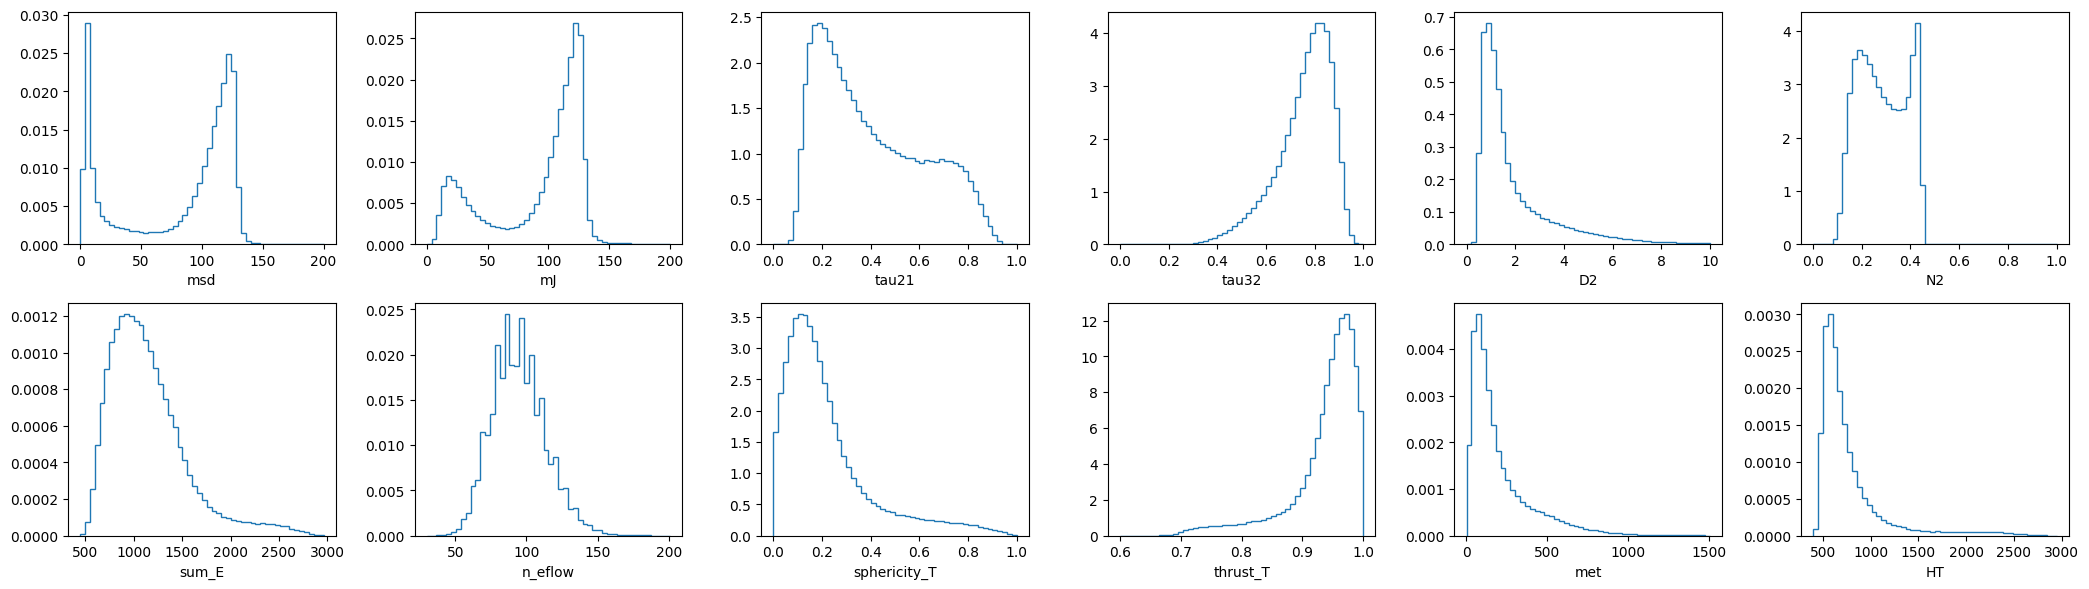

In [10]:
fig, ax = plt.subplots(2, 6, figsize=(21, 6))
jet_plots = [('msd', (0, 200)), ('mJ', (0, 200)), ('tau21', (0, 1)), ('tau32', (0, 1)), ('D2', (0, 10)), ('N2', (0, 1))]
evt_plots = [('sum_E', None), ('n_eflow', None), ('sphericity_T', (0, 1)), ('thrust_T', (0.6, 1)), ('met', None), ('HT', None)]
for a, (k, rng) in zip(ax[0], jet_plots):
    a.hist(out[k], bins=50, range=rng, weights=out['weight'], histtype='step', density=True); a.set_xlabel(k)
for a, (k, rng) in zip(ax[1], evt_plots):
    a.hist(evt[k], bins=50, range=rng, weights=evt['weight'], histtype='step', density=True); a.set_xlabel(k)
plt.tight_layout(); plt.show()

In [11]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:1292.8001(s)
